<a href="https://colab.research.google.com/github/SitiMutmainah15/PEMBELAJARAN-MESIN_GENAP_2026/blob/main/JS03/JS03_TUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("wbc.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
df = df.drop('id', axis=1)

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
encoder = LabelEncoder()

df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

In [9]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [10]:
X = df.drop('diagnosis', axis=1)

In [12]:
y = df['diagnosis']

In [13]:
X.shape

(569, 31)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
pipeline = Pipeline([

    ('scaler',
     StandardScaler()),


    ('selector',
     SelectKBest(
         score_func=f_classif,
         k=10
     )),


    ('model',
     LogisticRegression(max_iter=1000))

])

In [17]:
pipeline.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.13/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [19]:
df = df.dropna(axis=1)

In [20]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('selector', SelectKBest()),
                ('model', LogisticRegression(max_iter=1000))])

In [24]:
y_pred = pipeline.predict(X_test)


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Akurasi Model :", accuracy)

Akurasi Model : 0.9736842105263158


In [26]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[69,  2],
       [ 1, 42]])

In [28]:
hasil = []


for k in range(1,31):

    model = Pipeline([

        ('scaler',
         StandardScaler()),


        ('selector',
         SelectKBest(
             score_func=f_classif,
             k=k
         )),


        ('logistic',
         LogisticRegression(
             max_iter=1000
         ))

    ])


    model.fit(
        X_train,
        y_train
    )


    akurasi = model.score(
        X_test,
        y_test
    )


    hasil.append(
        [k, akurasi]
    )


hasil_df = pd.DataFrame(
    hasil,
    columns=[
        "Jumlah Fitur",
        "Akurasi"
    ]
)


hasil_df

,Jumlah Fitur,Akurasi
0,1,0.929825
1,2,0.938596
2,3,0.956140
3,4,0.973684
4,5,0.973684
5,6,0.973684
6,7,0.973684
7,8,0.973684
8,9,0.973684
9,10,0.973684


In [29]:
hasil_df.sort_values(
    by="Akurasi",
    ascending=False
).head(10)

,Jumlah Fitur,Akurasi
20,21,0.982456
17,18,0.982456
18,19,0.982456
19,20,0.982456
4,5,0.973684
3,4,0.973684
9,10,0.973684
21,22,0.973684
16,17,0.973684
15,16,0.973684


In [30]:
selector = SelectKBest(
    score_func=f_classif,
    k=10
)


selector.fit(
    X,
    y
)


fitur_terpilih = X.columns[
    selector.get_support()
]


fitur_terpilih

Index(['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean',
       'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='object')

In [31]:
hasil_df.sort_values(by="Akurasi", ascending=False).head()

,Jumlah Fitur,Akurasi
20,21,0.982456
17,18,0.982456
18,19,0.982456
19,20,0.982456
4,5,0.973684


In [34]:
fitur_terpilih

Index(['radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean',
       'concavity_mean', 'concave points_mean', 'radius_se', 'perimeter_se',
       'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
       'area_worst', 'smoothness_worst', 'compactness_worst',
       'concavity_worst', 'concave points_worst', 'symmetry_worst'],
      dtype='object')

In [33]:
selector = SelectKBest(
    score_func=f_classif,
    k=18
)


selector.fit(
    X,
    y
)


fitur_terpilih = X.columns[
    selector.get_support()
]


fitur_terpilih

Index(['radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean',
       'concavity_mean', 'concave points_mean', 'radius_se', 'perimeter_se',
       'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
       'area_worst', 'smoothness_worst', 'compactness_worst',
       'concavity_worst', 'concave points_worst', 'symmetry_worst'],
      dtype='object')

In [35]:
model_final = Pipeline([

    ('scaler',
     StandardScaler()),

    ('selector',
     SelectKBest(
         score_func=f_classif,
         k=18
     )),

    ('logistic',
     LogisticRegression(
         max_iter=1000
     ))

])

In [36]:
model_final.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()), ('selector', SelectKBest(k=18)),
                ('logistic', LogisticRegression(max_iter=1000))])

In [37]:
y_pred = model_final.predict(
    X_test
)

In [38]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.9824561403508771


In [39]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[71,  0],
       [ 2, 41]])

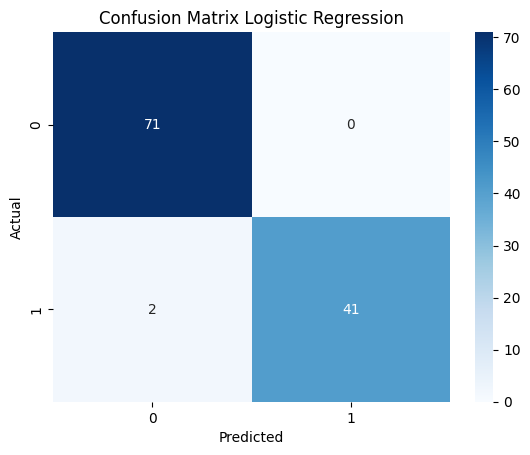

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Logistic Regression")

plt.show()